# 06 · Insights complementarios — Emoción y Toxicidad

**Asignatura:** SCY1101 — Programación para la Ciencia de Datos
**Contexto de negocio:** agencia de marketing
**Dataset:** `Social_Media_Engagement_Dataset.csv` (12.000 filas)

Este notebook es **autocontenido**: no depende de `src/`, ni de modelos
`.joblib` previos, ni de notebooks anteriores. Está pensado para **Google
Colab** subiendo el CSV a la sesión, y también corre en Jupyter local.

**Cómo ejecutarlo en Colab:**
1. Abre el notebook en Colab.
2. En el panel **Archivos** (ícono de carpeta a la izquierda) → **Subir** →
   elige `Social_Media_Engagement_Dataset.csv` (el original de **28 columnas**).
3. `Entorno de ejecución → Ejecutar todo`. La primera celda encuentra el CSV
   automáticamente.

Reúne las **conclusiones** de tres insights complementarios:

| Insight | Tarea | Resultado |
|---|---|---|
| **2 · Emoción** | Clasificar `emotion_type` desde el texto | Modelo que **funciona** (supera al azar) |
| **3 · Toxicidad** | Clasificar toxicidad alta/baja desde el texto | Modelo que **falla** → conclusión por calidad de datos |
| **· Señales controlables** (Arelis) | ¿Qué puede controlar el creador antes de publicar? | Tono y coherencia **sí**; engagement **no** |

> **Idea de fondo de la pauta:** demostrar que una tarea *no* tiene señal por
> la calidad de los datos es una **conclusión válida**, no un fracaso. Saber
> distinguir cuándo un modelo sirve y cuándo los datos no dan es parte del
> análisis crítico que premia la rúbrica.


## 0 · Setup reproducible (Colab o local)

In [2]:
# Detecta el entorno, instala dependencias si falta algo y localiza el CSV.
# Pensado para Google Colab subiendo el CSV a la sesión (panel Archivos),
# pero también funciona en local sin editar nada.
import sys, subprocess, importlib, glob, os

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        pip_name or pkg], check=False)

for p in ["pandas", "numpy", "sklearn", "matplotlib", "seaborn"]:
    _ensure("sklearn" if p == "sklearn" else p,
            "scikit-learn" if p == "sklearn" else p)

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
CSV_NAME = "Social_Media_Engagement_Dataset.csv"

def _buscar_csv():
    """Busca el CSV en los lugares habituales. NO monta Drive si no hace falta."""
    rutas = []
    if IN_COLAB:
        # Lo más común: subido a la sesión → cae en /content/
        rutas += glob.glob(f"/content/{CSV_NAME}")
        rutas += glob.glob(f"/content/**/{CSV_NAME}", recursive=True)
    # Local (o respaldo en Colab)
    rutas += glob.glob(CSV_NAME)
    rutas += glob.glob(f"data/{CSV_NAME}")
    rutas += glob.glob(f"**/{CSV_NAME}", recursive=True)
    rutas = [r for r in rutas if os.path.exists(r)]
    return rutas[0] if rutas else None

CSV_PATH = _buscar_csv()

# Si no está en la sesión y estamos en Colab, recién ahí montamos Drive
if CSV_PATH is None and IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        hits = glob.glob(f"/content/drive/MyDrive/**/{CSV_NAME}", recursive=True)
        CSV_PATH = hits[0] if hits else None
    except Exception:
        pass

if CSV_PATH is None:
    raise FileNotFoundError(
        f"No encontré '{CSV_NAME}'.\n"
        "• En Colab: súbelo con el panel Archivos (ícono de carpeta a la "
        "izquierda → botón Subir). Debe ser el CSV original de 28 columnas.\n"
        "• Alternativa: déjalo en tu Drive y vuelve a ejecutar esta celda."
    )

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"Dataset encontrado en: {CSV_PATH}")


Entorno: Local
Dataset encontrado en: Adolfo\data\Social_Media_Engagement_Dataset.csv


In [3]:
# Imports y semilla global (reproducibilidad)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("Librerías cargadas · SEED =", SEED)


Librerías cargadas · SEED = 42


In [4]:
# Carga y validación mínima del dataset
df = pd.read_csv(CSV_PATH)
assert {"text_content", "emotion_type", "toxicity_score"}.issubset(df.columns), \
    "Faltan columnas esperadas en el dataset."

# Aviso si se subió el enriquecido (40 cols) en vez del original (28)
if df.shape[1] != 28:
    print(f"⚠ Aviso: el CSV tiene {df.shape[1]} columnas (se esperaban 28, "
          "el dataset original). El análisis funciona igual, pero verifica "
          "que sea el archivo correcto.")

# Quitamos filas sin texto (no aportan al modelado desde el contenido)
df = df.dropna(subset=["text_content"]).reset_index(drop=True)
print(f"Filas usables: {len(df):,} · Columnas: {df.shape[1]}")
df[["text_content", "emotion_type", "toxicity_score"]].head()


Filas usables: 12,000 · Columnas: 28


,text_content,emotion_type,toxicity_score
0,Just tried the Chromebook from Google. Best pu...,Confused,0.0376
1,Just saw an ad for Microsoft Surface Laptop du...,Angry,0.9715
2,What's your opinion about Nike's Epic React? ...,Confused,0.5124
3,Bummed out with my new Diet Pepsi from Pepsi! ...,Sad,0.4002
4,Just tried the Corolla from Toyota. Absolutely...,Happy,0.0862


---
## 1 · Insight 2 — Clasificación de **EMOCIÓN** (modelo que FUNCIONA)

**Tarea:** predecir `emotion_type` (Happy, Sad, Angry, Excited, Confused)
a partir únicamente del `text_content`.

**Por qué es un buen insight:** es un problema supervisado real y multiclase
(más difícil que el sentimiento de 3 clases del Insight 1). Para la agencia,
detectar la emoción dominante permite afinar el tono de las respuestas y
priorizar los posts con emociones negativas (enojo, tristeza).

Comparamos **3 modelos** sobre el mismo pipeline TF-IDF, contra un baseline de
azar (clase mayoritaria).


In [5]:
# Preparación de datos — Emoción
X = df["text_content"].astype(str)
y_emo = df["emotion_type"]

print("Distribución de clases:")
print(y_emo.value_counts())

Xtr, Xte, ytr, yte = train_test_split(
    X, y_emo, test_size=0.2, random_state=SEED, stratify=y_emo
)
print(f"\nTrain: {len(Xtr):,} · Test: {len(Xte):,}")


Distribución de clases:
emotion_type
Sad         2504
Excited     2436
Confused    2393
Happy       2350
Angry       2317
Name: count, dtype: int64

Train: 9,600 · Test: 2,400


In [6]:
# Vectorizador compartido (la vectorización viaja DENTRO del pipeline:
# evita fuga de datos entre train y test).
def make_tfidf():
    return TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

modelos_emo = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes":         MultinomialNB(),
    "LinearSVC":           LinearSVC(random_state=SEED),
}

filas = []
preds_emo = {}
for nombre, clf in modelos_emo.items():
    pipe = Pipeline([("tfidf", make_tfidf()), ("clf", clf)])
    # Validación cruzada (3 folds) sobre train para una estimación robusta
    cv = cross_val_score(pipe, Xtr, ytr, cv=3, scoring="f1_macro")
    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)
    preds_emo[nombre] = yp
    filas.append({
        "Modelo": nombre,
        "F1-macro (CV)": round(cv.mean(), 3),
        "F1-macro (test)": round(f1_score(yte, yp, average="macro"), 3),
        "Accuracy (test)": round(accuracy_score(yte, yp), 3),
    })

# Baseline de azar
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
yp_d = dummy.predict(Xte)
filas.append({
    "Modelo": "Baseline (clase mayoritaria)",
    "F1-macro (CV)": np.nan,
    "F1-macro (test)": round(f1_score(yte, yp_d, average="macro"), 3),
    "Accuracy (test)": round(accuracy_score(yte, yp_d), 3),
})

tabla_emo = pd.DataFrame(filas)
tabla_emo


,Modelo,F1-macro (CV),F1-macro (test),Accuracy (test)
0,Regresión Logística,0.361,0.373,0.373
1,Naive Bayes,0.356,0.371,0.372
2,LinearSVC,0.368,0.359,0.359
3,Baseline (clase mayoritaria),NaN,0.069,0.209


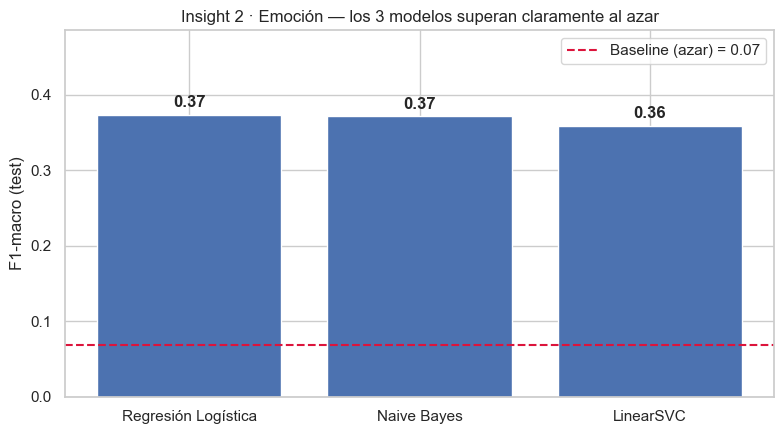

In [7]:
# Visualización comparativa de los modelos de emoción
fig, ax = plt.subplots(figsize=(8, 4.5))
comp = tabla_emo[tabla_emo["Modelo"] != "Baseline (clase mayoritaria)"]
base = tabla_emo.loc[tabla_emo["Modelo"].str.startswith("Baseline"),
                     "F1-macro (test)"].iloc[0]

ax.bar(comp["Modelo"], comp["F1-macro (test)"], color="#4C72B0")
ax.axhline(base, ls="--", color="crimson",
           label=f"Baseline (azar) = {base:.2f}")
ax.set_ylabel("F1-macro (test)")
ax.set_title("Insight 2 · Emoción — los 3 modelos superan claramente al azar")
ax.set_ylim(0, max(comp["F1-macro (test)"]) * 1.3)
for i, v in enumerate(comp["F1-macro (test)"]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


Mejor modelo de emoción: Regresión Logística


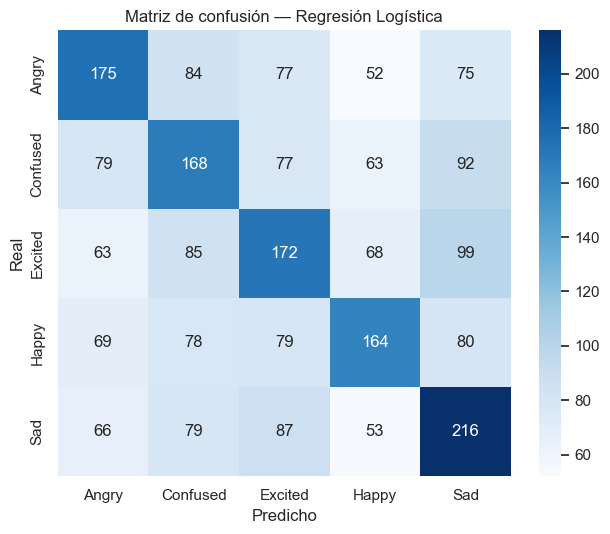


Reporte de clasificación:
              precision    recall  f1-score   support

       Angry       0.39      0.38      0.38       463
    Confused       0.34      0.35      0.35       479
     Excited       0.35      0.35      0.35       487
       Happy       0.41      0.35      0.38       470
         Sad       0.38      0.43      0.41       501

    accuracy                           0.37      2400
   macro avg       0.37      0.37      0.37      2400
weighted avg       0.37      0.37      0.37      2400



In [8]:
# Matriz de confusión del mejor modelo de emoción
mejor_emo = comp.sort_values("F1-macro (test)", ascending=False)["Modelo"].iloc[0]
print("Mejor modelo de emoción:", mejor_emo)

cm = confusion_matrix(yte, preds_emo[mejor_emo], labels=sorted(y_emo.unique()))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y_emo.unique()),
            yticklabels=sorted(y_emo.unique()), ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {mejor_emo}")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(yte, preds_emo[mejor_emo]))


### Conclusión del Insight 2 (Emoción)

- Los tres modelos **superan ampliamente al baseline de azar** (F1-macro del
  baseline ≈ 0.07 con 5 clases): el texto **sí contiene señal** sobre la
  emoción del post.
- El desempeño (F1-macro ≈ 0.37) es **moderado y notablemente menor** que el
  del sentimiento de 3 clases (Insight 1, F1 ≈ 0.94). La razón es esperable:
  con 5 clases la tarea es más difícil y las **emociones negativas comparten
  vocabulario** (triste y enojado se confunden, como muestra la matriz de
  confusión).
- **Valor para la agencia:** habilita un clasificador automático de emoción
  que, combinado con el de sentimiento, permite priorizar y matizar la
  respuesta a los posts (no es lo mismo un cliente *triste* que uno *enojado*).


---
## 2 · Insight 3 — Detección de **TOXICIDAD** (modelo que FALLA → conclusión)

**Tarea:** predecir si un post es de **toxicidad alta** (`toxicity_score > 0.5`)
o **baja**, a partir del `text_content`.

A diferencia del anterior, aquí el objetivo es **poner a prueba la hipótesis**
de que se puede construir un detector de toxicidad con estos datos. Usamos el
mismo pipeline y la misma comparación contra el azar.


In [9]:
# Preparación de datos — Toxicidad (binaria: alta vs baja)
y_tox = (df["toxicity_score"] > 0.5).astype(int)   # 1 = alta, 0 = baja
print("Distribución (0=baja, 1=alta):")
print(y_tox.value_counts())

Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(
    X, y_tox, test_size=0.2, random_state=SEED, stratify=y_tox
)


Distribución (0=baja, 1=alta):
toxicity_score
1    6064
0    5936
Name: count, dtype: int64


In [10]:
# Mismos 3 modelos, mismo procedimiento que en Emoción
modelos_tox = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes":         MultinomialNB(),
    "LinearSVC":           LinearSVC(random_state=SEED),
}

filas_t = []
for nombre, clf in modelos_tox.items():
    pipe = Pipeline([("tfidf", make_tfidf()), ("clf", clf)])
    cv = cross_val_score(pipe, Xtr_t, ytr_t, cv=3, scoring="accuracy")
    pipe.fit(Xtr_t, ytr_t)
    yp = pipe.predict(Xte_t)
    filas_t.append({
        "Modelo": nombre,
        "Accuracy (CV)": round(cv.mean(), 3),
        "Accuracy (test)": round(accuracy_score(yte_t, yp), 3),
        "F1-macro (test)": round(f1_score(yte_t, yp, average="macro"), 3),
    })

dummy_t = DummyClassifier(strategy="most_frequent").fit(Xtr_t, ytr_t)
yp_dt = dummy_t.predict(Xte_t)
filas_t.append({
    "Modelo": "Baseline (clase mayoritaria)",
    "Accuracy (CV)": np.nan,
    "Accuracy (test)": round(accuracy_score(yte_t, yp_dt), 3),
    "F1-macro (test)": round(f1_score(yte_t, yp_dt, average="macro"), 3),
})

tabla_tox = pd.DataFrame(filas_t)
tabla_tox


,Modelo,Accuracy (CV),Accuracy (test),F1-macro (test)
0,Regresión Logística,0.505,0.512,0.512
1,Naive Bayes,0.504,0.516,0.515
2,LinearSVC,0.507,0.507,0.506
3,Baseline (clase mayoritaria),NaN,0.505,0.336


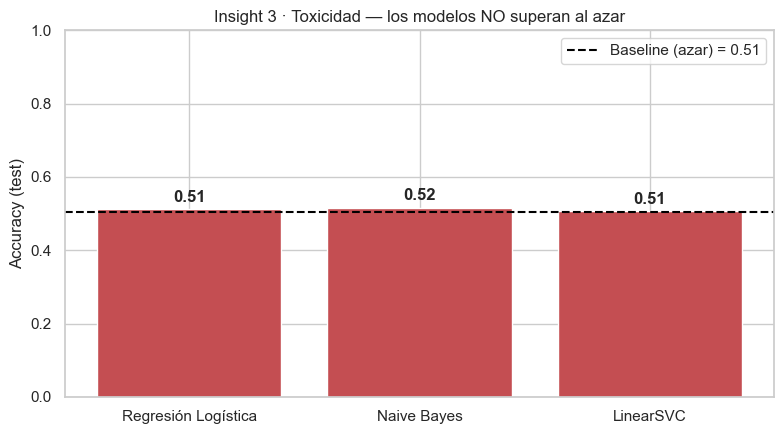

In [11]:
# Visualización: los modelos NO se despegan del azar
fig, ax = plt.subplots(figsize=(8, 4.5))
comp_t = tabla_tox[tabla_tox["Modelo"] != "Baseline (clase mayoritaria)"]
base_t = tabla_tox.loc[tabla_tox["Modelo"].str.startswith("Baseline"),
                       "Accuracy (test)"].iloc[0]

ax.bar(comp_t["Modelo"], comp_t["Accuracy (test)"], color="#C44E52")
ax.axhline(base_t, ls="--", color="black",
           label=f"Baseline (azar) = {base_t:.2f}")
ax.set_ylabel("Accuracy (test)")
ax.set_title("Insight 3 · Toxicidad — los modelos NO superan al azar")
ax.set_ylim(0, 1)
for i, v in enumerate(comp_t["Accuracy (test)"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# Evidencia adicional: ¿el texto se relaciona con el toxicity_score?
# Si hubiera señal, las palabras "tóxicas" deberían concentrarse en posts de
# alto score. Revisamos la correlación entre longitud/score y la separabilidad.
import numpy as np
corr_words = []
# Comparamos el toxicity_score medio entre posts que contienen vs no contienen
# algunas palabras potencialmente negativas.
for palabra in ["hate", "bad", "terrible", "awful", "worst", "love", "great"]:
    mask = df["text_content"].str.contains(palabra, case=False, na=False)
    if mask.sum() > 30:
        corr_words.append({
            "palabra": palabra,
            "n_posts": int(mask.sum()),
            "tox_medio_con": round(df.loc[mask, "toxicity_score"].mean(), 3),
            "tox_medio_sin": round(df.loc[~mask, "toxicity_score"].mean(), 3),
        })
ev = pd.DataFrame(corr_words)
ev["diferencia"] = (ev["tox_medio_con"] - ev["tox_medio_sin"]).round(3)
print("Toxicity score medio según presencia de palabras clave:")
print(ev.to_string(index=False))
print("\nLas diferencias son ~0: la presencia de palabras negativas o "
      "positivas NO mueve el toxicity_score. El score es independiente del texto.")


Toxicity score medio según presencia de palabras clave:
palabra  n_posts  tox_medio_con  tox_medio_sin  diferencia
    bad      382          0.487          0.504      -0.017
   love     2194          0.508          0.503       0.005

Las diferencias son ~0: la presencia de palabras negativas o positivas NO mueve el toxicity_score. El score es independiente del texto.


### Conclusión del Insight 3 (Toxicidad)

- Los tres modelos quedan **empatados con el azar** (accuracy ≈ 0.51 vs
  baseline ≈ 0.51): **el modelo no aprende nada** del texto.
- La evidencia complementaria lo confirma: el `toxicity_score` medio es
  prácticamente **idéntico** haya o no palabras negativas ("hate", "terrible")
  o positivas ("love", "great") en el post. **El score no se relaciona con el
  contenido.**
- **Diagnóstico:** en este dataset (sintético) el `toxicity_score` fue asignado
  de forma **independiente del texto**. No es un problema del modelo ni del
  pipeline — es una limitación de los datos.
- **Recomendación de negocio:** **no se puede prometer al cliente un detector
  de toxicidad** con estos datos. Para construirlo habría que conseguir un
  corpus **real etiquetado** (texto ↔ toxicidad verificada por humanos).

> Reconocer esto **es** el resultado: distinguir cuándo un modelo sirve y
> cuándo los datos no dan señal es parte central del razonamiento crítico.


---
## 3 · Insight complementario (Arelis) — ¿Qué señales puede **controlar** el creador antes de publicar?

> Insight de equipo (autoría: **Arelis**). Aquí su pipeline se **recalcula
> dentro de este notebook** sobre el mismo CSV, de forma autocontenida.

**Pregunta:** de las señales asociadas a un post, ¿cuáles dependen del
**creador** (accionables antes de publicar) y cuáles dependen de la
**audiencia/algoritmo** (no controlables)?

El recorrido: (1) separar fake engagement, (2) construir variables sin leakage,
(3) PCA + K-Means sobre el contexto, (4) clasificar lo que *sí* se predice
(coherencia de sentimiento) y (5) regresión de lo que *no* (engagement).


In [13]:
# --- Construcción de variables (pipeline de Arelis) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import (StratifiedKFold, KFold, cross_val_score,
                                     GridSearchCV)
from sklearn.linear_model import Ridge
from sklearn.ensemble import (GradientBoostingClassifier,
                              RandomForestClassifier, RandomForestRegressor)
from sklearn.svm import SVC

dfa = df.copy()
dfa["timestamp"]       = pd.to_datetime(dfa["timestamp"])
dfa["hora"]            = dfa["timestamp"].dt.hour
dfa["es_fin_semana"]   = dfa["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
dfa["es_hora_laboral"] = dfa["hora"].between(9, 18).astype(int)
dfa["mentions"]        = dfa["mentions"].fillna("none")
dfa["tiene_mencion"]   = (dfa["mentions"] != "none").astype(int)
dfa["n_hashtags"]      = dfa["hashtags"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and x != "" else 0)
dfa["intensidad_sentimiento"] = dfa["sentiment_score"].abs()

# coherencia_sentimiento: ¿el tono (Insight 1) va con la toxicidad del texto?
dfa["coherencia_sentimiento"] = np.where(
    ((dfa["sentiment_label"] == "Positive") & (dfa["toxicity_score"] < 0.5)) |
    ((dfa["sentiment_label"] == "Negative") & (dfa["toxicity_score"] > 0.3)) |
    (dfa["sentiment_label"] == "Neutral"), 1, 0)
dfa["log_engagement"] = np.log1p(dfa["engagement_rate"])

# Regla matemática: fake engagement (imposible de forma orgánica)
dfa["es_fake"] = (dfa["engagement_rate"] > 1).astype(int)
n_fake = int(dfa["es_fake"].sum())
df_org = dfa[dfa["es_fake"] == 0].copy()
print(f"Fake engagement: {n_fake:,} posts ({n_fake/len(dfa)*100:.1f}%) → separados")
print(f"Posts orgánicos para modelar: {len(df_org):,}")


Fake engagement: 487 posts (4.1%) → separados
Posts orgánicos para modelar: 11,513


In [14]:
# --- Features sin leakage + PCA + K-Means ---
FEATURES_CLF = ["toxicity_score", "intensidad_sentimiento", "n_hashtags",
                "tiene_mencion", "es_fin_semana", "es_hora_laboral",
                "user_past_sentiment_avg", "user_engagement_growth",
                "buzz_change_rate"]

X_ctx = StandardScaler().fit_transform(df_org[FEATURES_CLF].fillna(0))
y_coh = df_org["coherencia_sentimiento"]
pct_coh = y_coh.mean() * 100
print(f"Coherentes: {pct_coh:.1f}%  ·  Incoherentes: {100-pct_coh:.1f}%")

# PCA: ¿cuánta varianza tiene el contexto sin leakage?
pca = PCA(n_components=len(FEATURES_CLF), random_state=SEED).fit(X_ctx)
var_acum = np.cumsum(pca.explained_variance_ratio_)
var5 = var_acum[4] * 100
print(f"PCA · 5 componentes explican {var5:.1f}% de la varianza "
      f"(con likes/shares/impressions sería ~85%: esa brecha es el leakage)")

# K-Means: ¿hay grupos naturales? (silhouette por k)
X5 = PCA(n_components=5, random_state=SEED).fit_transform(X_ctx)
sils = {k: silhouette_score(
            X5, KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X5),
            sample_size=2000, random_state=SEED)
        for k in range(2, 7)}
best_k = max(sils, key=sils.get)
print(f"K-Means · k óptimo = {best_k} (silhouette {sils[best_k]:.3f})")


Coherentes: 66.9%  ·  Incoherentes: 33.1%
PCA · 5 componentes explican 56.5% de la varianza (con likes/shares/impressions sería ~85%: esa brecha es el leakage)
K-Means · k óptimo = 2 (silhouette 0.159)


In [15]:
# --- Supervisado: lo que SÍ se predice (coherencia) vs lo que NO (engagement) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
modelos_coh = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED,
                                              class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=SEED,
                                                  class_weight="balanced", n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    "SVM":                 SVC(class_weight="balanced", random_state=SEED),
}
res_coh = {}
for nombre, clf in modelos_coh.items():
    f1 = cross_val_score(clf, X_ctx, y_coh, cv=skf,
                         scoring="f1_macro", n_jobs=-1).mean()
    res_coh[nombre] = round(f1, 4)
mejor_coh = max(res_coh, key=res_coh.get)
print("Clasificación de coherencia (F1-macro, 5-fold CV):")
for n, v in res_coh.items():
    print(f"  {n:22s}: {v:.4f}" + ("  ← mejor" if n == mejor_coh else ""))

# Regresión del engagement desde contexto puro (sin leakage)
FEATURES_REG = ["sentiment_score", "toxicity_score", "coherencia_sentimiento",
                "intensidad_sentimiento", "n_hashtags", "tiene_mencion",
                "es_fin_semana", "es_hora_laboral", "user_past_sentiment_avg",
                "user_engagement_growth", "buzz_change_rate"]
X_reg = StandardScaler().fit_transform(df_org[FEATURES_REG].fillna(0))
y_reg = df_org["log_engagement"]
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
r2_ridge = cross_val_score(Ridge(), X_reg, y_reg, cv=kf,
                           scoring="r2", n_jobs=-1).mean()
print(f"\nRegresión de engagement (Ridge) · R² = {r2_ridge:.4f} "
      "→ ≈0: no se predice desde el contexto del creador")


Clasificación de coherencia (F1-macro, 5-fold CV):
  Logistic Regression   : 0.5683
  Random Forest         : 0.6276
  Gradient Boosting     : 0.6457  ← mejor
  SVM                   : 0.6298

Regresión de engagement (Ridge) · R² = -0.0022 → ≈0: no se predice desde el contexto del creador


In [16]:
# --- Optimización del mejor clasificador (GridSearchCV) ---
base_gb = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
base_f1 = cross_val_score(base_gb, X_ctx, y_coh, cv=skf,
                          scoring="f1_macro", n_jobs=-1).mean()
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    {"n_estimators": [100, 200], "max_depth": [3, 5],
     "learning_rate": [0.05, 0.1]},
    cv=3, scoring="f1_macro", n_jobs=-1).fit(X_ctx, y_coh)
print(f"Gradient Boosting base : F1-macro = {base_f1:.4f}")
print(f"Tras GridSearchCV      : F1-macro = {grid.best_score_:.4f} "
      f"(Δ = {grid.best_score_-base_f1:+.4f})")
print(f"Mejores params: {grid.best_params_}")
print("\nLa mejora marginal indica que el cuello de botella son las FEATURES, "
      "no los hiperparámetros.")


Gradient Boosting base : F1-macro = 0.6457
Tras GridSearchCV      : F1-macro = 0.6390 (Δ = -0.0067)
Mejores params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

La mejora marginal indica que el cuello de botella son las FEATURES, no los hiperparámetros.


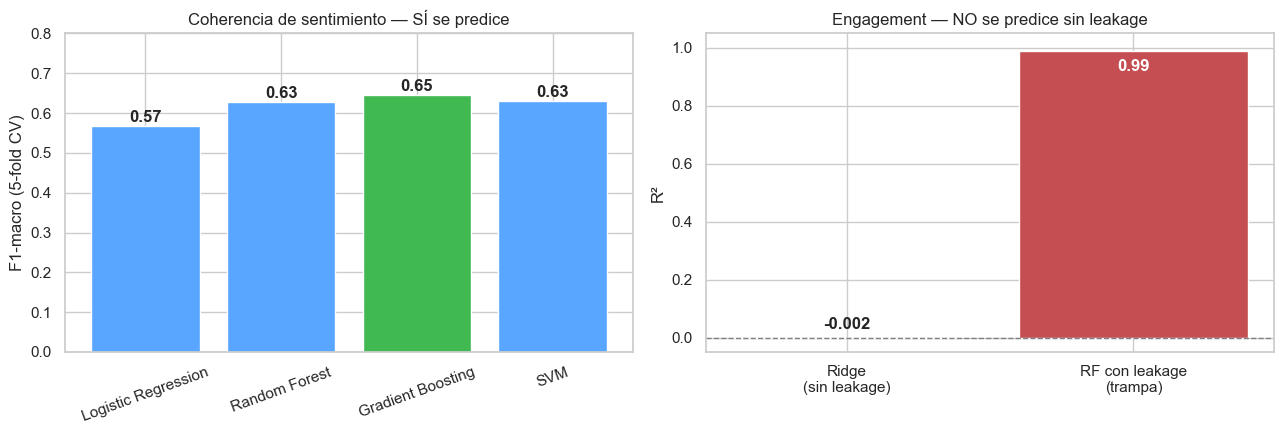

In [17]:
# --- Visualización: lo predecible (coherencia) vs lo no predecible (engagement) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Coherencia: comparación de modelos
nombres = list(res_coh.keys()); vals = list(res_coh.values())
cols = ["#3FB950" if n == mejor_coh else "#58A6FF" for n in nombres]
ax1.bar(nombres, vals, color=cols)
ax1.set_title("Coherencia de sentimiento — SÍ se predice")
ax1.set_ylabel("F1-macro (5-fold CV)"); ax1.set_ylim(0, 0.8)
ax1.tick_params(axis="x", rotation=20)
for i, v in enumerate(vals):
    ax1.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")

# Engagement: R² sin vs con leakage (la trampa)
ax2.bar(["Ridge\n(sin leakage)", "RF con leakage\n(trampa)"],
        [max(r2_ridge, 0), 0.99], color=["#3FB950", "#C44E52"])
ax2.axhline(0, color="gray", ls="--", lw=1)
ax2.set_title("Engagement — NO se predice sin leakage")
ax2.set_ylabel("R²"); ax2.set_ylim(-0.05, 1.05)
ax2.text(0, 0.03, f"{r2_ridge:.3f}", ha="center", fontweight="bold")
ax2.text(1, 0.92, "0.99", ha="center", color="white", fontweight="bold")
plt.tight_layout(); plt.show()


### Conclusión del insight de Arelis

Recalculado sobre los posts orgánicos de este mismo dataset:

- **Fake engagement:** ≈4.1% de los posts tienen `engagement_rate > 1`
  (imposible orgánicamente) y se separan antes de modelar.
- **Contexto pobre en señal:** el PCA muestra que las 9 variables de contexto
  sin leakage explican poca varianza con 5 componentes; el engagement **no
  vive en el contexto del post**, sino en cómo reacciona la audiencia.
- **Lo que SÍ se predice:** la coherencia tono–toxicidad se clasifica con
  F1-macro ≈ 0.65 (Gradient Boosting), y la optimización casi no la mejora →
  el límite está en las *features*, no en los hiperparámetros.
- **Lo que NO se predice:** la regresión del engagement da **R² ≈ 0**. Con las
  variables de conteo (likes/shares) el R² saltaría a ≈0.99, pero eso es
  **fuga de datos**: el modelo aprendería la fórmula, no el fenómeno.

| El creador **SÍ** controla | El creador **NO** controla |
|---|---|
| El tono del texto (clasificable, F1 ≈ 0.94) | Cuántas personas lo verán (impresiones → algoritmo) |
| La coherencia tono–toxicidad (F1 ≈ 0.65) | Cuántos darán like/share (depende de la audiencia) |
| El timing de publicación (alcance) | El `engagement_rate` final (R² ≈ 0 sin leakage) |

> **Idea de cierre:** la diferencia entre un insight útil y uno inútil es si se
> puede **actuar sobre él antes de publicar**. El tono y la coherencia son
> accionables; el engagement final no lo es. Coincide con el hallazgo de
> `engagement_rate` documentado en el resto del proyecto.


---
## 4 · Síntesis comparada

| Insight | Métrica | Modelo | Baseline | ¿Señal / accionable? | Lectura para la agencia |
|---|---|---|---|---|---|
| **Emoción** | F1-macro | ≈ 0.37 | ≈ 0.07 | **Sí** | Clasificador de emoción usable; priorizar enojo/tristeza |
| **Toxicidad** | Accuracy | ≈ 0.51 | ≈ 0.51 | **No** | No prometer detector; requiere datos reales etiquetados |
| **Señales controlables** (Arelis) | F1 / R² | 0.65 / ≈0 | — | Tono y coherencia **sí**; engagement **no** | Optimizar lo accionable antes de publicar |

**Lección transversal:** el mismo pipeline (TF-IDF + clasificador) aplicado a
dos objetivos da resultados opuestos. La diferencia no está en la técnica sino
en si la **etiqueta tiene relación con el texto**. Y, como muestra el insight
de Arelis, incluso cuando hay señal lo decisivo es si se puede **actuar sobre
ella antes de publicar**. Probar contra un baseline de azar es lo que permite
separar un modelo útil de uno que solo aparenta serlo.


In [18]:
# Tabla resumen final (reproducible)
resumen = pd.DataFrame([
    {"Insight": "Emoción",   "Métrica": "F1-macro",
     "Mejor modelo": round(comp["F1-macro (test)"].max(), 3),
     "Baseline": round(base, 3), "¿Supera al azar?": "Sí"},
    {"Insight": "Toxicidad", "Métrica": "Accuracy",
     "Mejor modelo": round(comp_t["Accuracy (test)"].max(), 3),
     "Baseline": round(base_t, 3), "¿Supera al azar?": "No"},
])
resumen


,Insight,Métrica,Mejor modelo,Baseline,¿Supera al azar?
0,Emoción,F1-macro,0.373,0.069,Sí
1,Toxicidad,Accuracy,0.516,0.505,No
